# Selecao auxiliar de imagens para unmixing CNNAEU

Este notebook ajuda a escolher quais imagens hiperespectrais serao avaliadas no fluxo de unmixing por imagem unica.

Ele reutiliza os metodos existentes do projeto para ler STIFF, converter a imagem para reflectancia no modo de treino e gerar o RGB de inspecao. As metricas abaixo sao heuristicas: servem para priorizar cenas variadas, com boa faixa dinamica e sem problemas obvios de escala, mas nao substituem a avaliacao do modelo treinado.

In [1]:
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

cwd = Path.cwd().resolve()
if (cwd / 'src').exists():
    REPO_ROOT = cwd
elif (cwd.parent / 'src').exists():
    REPO_ROOT = cwd.parent
else:
    raise RuntimeError('Execute este notebook a partir da raiz do repositorio ou da pasta notebooks.')

os.chdir(REPO_ROOT)
SRC_PATH = REPO_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from torchseg.data_loader import OdsiDbDataLoader, read_stiff

LoadImage = OdsiDbDataLoader.LoadImage
print(f'Repo root: {REPO_ROOT}')

Repo root: /home/ranulfo/projects/tcc/references/segodsidb


## Parametros

Ajuste `DATA_DIRS` para procurar imagens em `train`, `test` ou em uma pasta especifica. O notebook ignora automaticamente arquivos `*_masks.tif`.

In [2]:
DATA_DIRS = [
    Path('../odsi_db/folds/fold_0/train'),
    Path('../odsi_db/folds/fold_0/test'),
]

MODE = 'simage_170'
MAX_IMAGES = None          # use um inteiro para testar rapidamente, ex.: 20
MAX_STAT_PIXELS = 150_000  # amostra deterministica para estatisticas rapidas
SEED = 42

THUMBNAIL_DIR = Path('results/image_selection_thumbnails')
OUTPUT_CSV = Path('results/selected_unmixing_images.csv')
CONFIG_PATH = Path('config_templates/unmixing/odsi_db/repro/fold_0/cnnaeu_simage_170.json')

TARGET_WAVELENGTHS = OdsiDbDataLoader.mode2wl[MODE]
print(f'Modo: {MODE} | bandas alvo: {len(TARGET_WAVELENGTHS)}')

Modo: simage_170 | bandas alvo: 170


In [3]:
def is_hsi_tif(path: Path) -> bool:
    return path.suffix.lower() in {'.tif', '.tiff'} and not path.name.endswith('_masks.tif')


def list_hsi_images(data_dirs):
    paths = []
    for data_dir in data_dirs:
        data_dir = Path(data_dir)
        if not data_dir.exists():
            print(f'Aviso: pasta nao encontrada: {data_dir}')
            continue
        paths.extend(sorted(p for p in data_dir.glob('*.tif') if is_hsi_tif(p)))
        paths.extend(sorted(p for p in data_dir.glob('*.tiff') if is_hsi_tif(p)))
    return sorted(dict.fromkeys(paths))


def infer_view(path: Path) -> str:
    name = path.stem.lower()
    for token in ['top', 'bottom', 'face', 'wide', 'front']:
        if token in name:
            return token
    return 'unknown'


def sample_pixels(reflectance: np.ndarray, max_pixels: int, seed: int):
    flat = reflectance.reshape(-1, reflectance.shape[-1])
    if max_pixels is None or flat.shape[0] <= max_pixels:
        return flat
    rng = np.random.default_rng(seed)
    idx = rng.choice(flat.shape[0], size=max_pixels, replace=False)
    return flat[idx]


def analyze_image(path: Path, mode: str = MODE, seed: int = SEED):
    im_hyper, wl, _, metadata = read_stiff(str(path), silent=True, rgb_only=False)
    reflectance = LoadImage.read_hyper_reflectance(str(path), mode, im_hyper=im_hyper, wl=wl)
    rgb = LoadImage.hyper2rgb(im_hyper, wl)

    THUMBNAIL_DIR.mkdir(parents=True, exist_ok=True)
    thumbnail_path = THUMBNAIL_DIR / f'{path.stem}.png'
    plt.imsave(thumbnail_path, rgb)

    sample = sample_pixels(reflectance, MAX_STAT_PIXELS, seed)
    finite = np.isfinite(sample)
    finite_sample = sample[finite]
    if finite_sample.size == 0:
        raise ValueError('Imagem sem valores finitos na reflectancia.')

    band_mean = np.nanmean(sample, axis=0)
    band_std = np.nanstd(sample, axis=0)
    p01, p05, p50, p95, p99 = np.nanquantile(sample, [0.01, 0.05, 0.50, 0.95, 0.99])

    h, w, raw_bands = im_hyper.shape
    target_bands = reflectance.shape[-1]
    return {
        'path': str(path),
        'filename': path.name,
        'split': path.parent.name,
        'view': infer_view(path),
        'height': int(h),
        'width': int(w),
        'area_pixels': int(h * w),
        'raw_bands': int(raw_bands),
        'target_bands': int(target_bands),
        'reflectance_mean': float(np.nanmean(sample)),
        'reflectance_std': float(np.nanstd(sample)),
        'reflectance_p01': float(p01),
        'reflectance_p05': float(p05),
        'reflectance_median': float(p50),
        'reflectance_p95': float(p95),
        'reflectance_p99': float(p99),
        'dynamic_range_p99_p01': float(p99 - p01),
        'spectral_mean_std': float(np.nanstd(band_mean)),
        'spatial_std_mean': float(np.nanmean(band_std)),
        'negative_frac': float(np.mean(sample < 0.0)),
        'above_one_frac': float(np.mean(sample > 1.0)),
        'near_zero_frac': float(np.mean(sample < 0.01)),
        'nonfinite_frac': float(1.0 - np.mean(finite)),
        'thumbnail': str(thumbnail_path),
        'error': None,
    }

## Varredura das imagens

Esta celula le cada imagem uma vez, salva miniaturas RGB e calcula estatisticas de reflectancia no mesmo modo usado pelo treino.

In [4]:
images = list_hsi_images(DATA_DIRS)
if MAX_IMAGES is not None:
    images = images[:MAX_IMAGES]

print(f'Imagens encontradas: {len(images)}')
rows = []
for i, path in enumerate(images, start=1):
    try:
        rows.append(analyze_image(path))
    except Exception as exc:
        rows.append({
            'path': str(path),
            'filename': path.name,
            'split': path.parent.name,
            'view': infer_view(path),
            'error': repr(exc),
        })
    if i % 10 == 0 or i == len(images):
        print(f'Processadas: {i}/{len(images)}')

df_raw = pd.DataFrame(rows)
display(df_raw.head())

errors = df_raw[df_raw['error'].notna()] if 'error' in df_raw else pd.DataFrame()
if len(errors):
    print('Imagens com erro:')
    display(errors[['filename', 'path', 'error']])

Imagens encontradas: 215
Processadas: 10/215
Processadas: 20/215
Processadas: 30/215
Processadas: 40/215
Processadas: 50/215
Processadas: 60/215
Processadas: 70/215
Processadas: 80/215
Processadas: 90/215
Processadas: 100/215
Processadas: 110/215
Processadas: 120/215
Processadas: 130/215
Processadas: 140/215
Processadas: 150/215
Processadas: 160/215
Processadas: 170/215
Processadas: 180/215
Processadas: 190/215
Processadas: 200/215
Processadas: 210/215
Processadas: 215/215


,path,filename,split,view,height,width,area_pixels,raw_bands,target_bands,reflectance_mean,...,reflectance_p99,dynamic_range_p99_p01,spectral_mean_std,spatial_std_mean,negative_frac,above_one_frac,near_zero_frac,nonfinite_frac,thumbnail,error
0,../odsi_db/folds/fold_0/test/0cd801fd_top_1.tif,0cd801fd_top_1.tif,test,top,512,512,262144,204,170,0.301921,...,0.911419,0.907619,0.092017,0.215623,0.0,0.0,0.071807,0.0,results/image_selection_thumbnails/0cd801fd_to...,None
1,../odsi_db/folds/fold_0/test/43ebce65_wide_4.tif,43ebce65_wide_4.tif,test,wide,512,512,262144,204,170,0.047852,...,0.173166,0.172562,0.017322,0.031375,0.0,0.0,0.142502,0.0,results/image_selection_thumbnails/43ebce65_wi...,None
2,../odsi_db/folds/fold_0/test/45d3d05a_face_2.tif,45d3d05a_face_2.tif,test,face,243,458,111294,204,170,0.168311,...,0.578875,0.577158,0.052252,0.131896,0.0,0.0,0.071948,0.0,results/image_selection_thumbnails/45d3d05a_fa...,None
3,../odsi_db/folds/fold_0/test/4a53ee14_top_2.tif,4a53ee14_top_2.tif,test,top,512,512,262144,204,170,0.151961,...,0.527338,0.524975,0.050541,0.107301,0.0,0.0,0.094480,0.0,results/image_selection_thumbnails/4a53ee14_to...,None
4,../odsi_db/folds/fold_0/test/4cfae92f_bottom_i...,4cfae92f_bottom_inpaint_GDBICP_similarity.tif,test,bottom,1040,1392,1447680,51,170,0.104341,...,0.338666,0.324366,0.033616,0.060368,0.0,0.0,0.006267,0.0,results/image_selection_thumbnails/4cfae92f_bo...,None


## Ranking heuristico

O score favorece imagens com variacao espacial/espectral e boa faixa dinamica. Ele penaliza valores nao finitos, reflectancia fora de faixa e imagens excessivamente escuras. Ajuste os pesos se quiser priorizar outro criterio.

In [5]:
def rank_pct(series, ascending=True):
    return series.rank(pct=True, ascending=ascending).fillna(0.0)


valid = df_raw[df_raw['error'].isna()].copy()
if valid.empty:
    raise RuntimeError('Nenhuma imagem valida foi analisada.')

median_distance = (valid['reflectance_median'] - valid['reflectance_median'].median()).abs()
valid['selection_score'] = (
    0.35 * rank_pct(valid['spatial_std_mean'])
    + 0.25 * rank_pct(valid['spectral_mean_std'])
    + 0.20 * rank_pct(valid['dynamic_range_p99_p01'])
    + 0.10 * rank_pct(valid['reflectance_std'])
    + 0.10 * rank_pct(valid['area_pixels'])
    - 0.25 * rank_pct(median_distance)
    - 0.20 * rank_pct(valid['above_one_frac'])
    - 0.20 * rank_pct(valid['negative_frac'])
    - 0.15 * rank_pct(valid['near_zero_frac'])
    - 0.30 * rank_pct(valid['nonfinite_frac'])
)

df_ranked = valid.sort_values('selection_score', ascending=False).reset_index(drop=True)
columns = [
    'filename', 'split', 'view', 'raw_bands', 'target_bands',
    'reflectance_mean', 'reflectance_std', 'dynamic_range_p99_p01',
    'spectral_mean_std', 'spatial_std_mean', 'negative_frac',
    'above_one_frac', 'near_zero_frac', 'selection_score', 'path'
]
display(df_ranked[columns].head(30))

,filename,split,view,raw_bands,target_bands,reflectance_mean,reflectance_std,dynamic_range_p99_p01,spectral_mean_std,spatial_std_mean,negative_frac,above_one_frac,near_zero_frac,selection_score,path
0,e0053b84_bottom_7.tif,train,bottom,204,170,0.204747,0.185072,0.852977,0.069140,0.163270,0.0,0.0,0.006981,0.398837,../odsi_db/folds/fold_0/train/e0053b84_bottom_...
1,0aa155fa_front_2.tif,train,front,204,170,0.227168,0.184691,0.860440,0.071937,0.165943,0.0,0.0,0.005515,0.353488,../odsi_db/folds/fold_0/train/0aa155fa_front_2...
2,2773ccf1_front_2.tif,train,front,204,170,0.251868,0.197623,0.896028,0.080602,0.177292,0.0,0.0,0.002252,0.346977,../odsi_db/folds/fold_0/train/2773ccf1_front_2...
3,3a4ab068_bottom_2.tif,train,bottom,204,170,0.191005,0.174416,0.730851,0.071692,0.148937,0.0,0.0,0.004598,0.339767,../odsi_db/folds/fold_0/train/3a4ab068_bottom_...
4,4f86dd9c_front_1.tif,train,front,204,170,0.221954,0.180713,0.842530,0.070576,0.161892,0.0,0.0,0.007564,0.338837,../odsi_db/folds/fold_0/train/4f86dd9c_front_1...
5,5d65db43_bottom_2.tif,train,bottom,204,170,0.469485,0.336856,0.987180,0.143006,0.295953,0.0,0.0,0.000628,0.336977,../odsi_db/folds/fold_0/train/5d65db43_bottom_...
6,a03af337_top_3.tif,train,top,204,170,0.199217,0.164022,0.694364,0.066829,0.142089,0.0,0.0,0.002127,0.336512,../odsi_db/folds/fold_0/train/a03af337_top_3.tif
7,09d077e3_front_2.tif,train,front,204,170,0.404298,0.286108,0.962550,0.125370,0.254519,0.0,0.0,0.000000,0.335349,../odsi_db/folds/fold_0/train/09d077e3_front_2...
8,5565f021_front_1.tif,train,front,204,170,0.252534,0.194676,0.913230,0.080959,0.173994,0.0,0.0,0.000552,0.330000,../odsi_db/folds/fold_0/train/5565f021_front_1...
9,7388b887_front_1.tif,train,front,204,170,0.265695,0.201187,0.849126,0.086981,0.177635,0.0,0.0,0.006131,0.328372,../odsi_db/folds/fold_0/train/7388b887_front_1...


## Filtros recomendados

Use estes filtros como ponto de partida. A ideia e evitar cenas com muitos valores problematicos e manter imagens com faixa dinamica suficiente para unmixing.

In [6]:
MIN_DYNAMIC_RANGE = 0.05
MAX_NEGATIVE_FRAC = 0.001
MAX_ABOVE_ONE_FRAC = 0.02
MAX_NONFINITE_FRAC = 0.0

candidates = df_ranked[
    (df_ranked['dynamic_range_p99_p01'] >= MIN_DYNAMIC_RANGE)
    & (df_ranked['negative_frac'] <= MAX_NEGATIVE_FRAC)
    & (df_ranked['above_one_frac'] <= MAX_ABOVE_ONE_FRAC)
    & (df_ranked['nonfinite_frac'] <= MAX_NONFINITE_FRAC)
].copy()

if candidates.empty:
    print('Nenhuma imagem passou nos filtros; mostrando o ranking completo.')
    candidates = df_ranked.copy()

display(candidates[columns].head(30))

,filename,split,view,raw_bands,target_bands,reflectance_mean,reflectance_std,dynamic_range_p99_p01,spectral_mean_std,spatial_std_mean,negative_frac,above_one_frac,near_zero_frac,selection_score,path
0,e0053b84_bottom_7.tif,train,bottom,204,170,0.204747,0.185072,0.852977,0.069140,0.163270,0.0,0.0,0.006981,0.398837,../odsi_db/folds/fold_0/train/e0053b84_bottom_...
1,0aa155fa_front_2.tif,train,front,204,170,0.227168,0.184691,0.860440,0.071937,0.165943,0.0,0.0,0.005515,0.353488,../odsi_db/folds/fold_0/train/0aa155fa_front_2...
2,2773ccf1_front_2.tif,train,front,204,170,0.251868,0.197623,0.896028,0.080602,0.177292,0.0,0.0,0.002252,0.346977,../odsi_db/folds/fold_0/train/2773ccf1_front_2...
3,3a4ab068_bottom_2.tif,train,bottom,204,170,0.191005,0.174416,0.730851,0.071692,0.148937,0.0,0.0,0.004598,0.339767,../odsi_db/folds/fold_0/train/3a4ab068_bottom_...
4,4f86dd9c_front_1.tif,train,front,204,170,0.221954,0.180713,0.842530,0.070576,0.161892,0.0,0.0,0.007564,0.338837,../odsi_db/folds/fold_0/train/4f86dd9c_front_1...
5,5d65db43_bottom_2.tif,train,bottom,204,170,0.469485,0.336856,0.987180,0.143006,0.295953,0.0,0.0,0.000628,0.336977,../odsi_db/folds/fold_0/train/5d65db43_bottom_...
6,a03af337_top_3.tif,train,top,204,170,0.199217,0.164022,0.694364,0.066829,0.142089,0.0,0.0,0.002127,0.336512,../odsi_db/folds/fold_0/train/a03af337_top_3.tif
7,09d077e3_front_2.tif,train,front,204,170,0.404298,0.286108,0.962550,0.125370,0.254519,0.0,0.0,0.000000,0.335349,../odsi_db/folds/fold_0/train/09d077e3_front_2...
8,5565f021_front_1.tif,train,front,204,170,0.252534,0.194676,0.913230,0.080959,0.173994,0.0,0.0,0.000552,0.330000,../odsi_db/folds/fold_0/train/5565f021_front_1...
9,7388b887_front_1.tif,train,front,204,170,0.265695,0.201187,0.849126,0.086981,0.177635,0.0,0.0,0.006131,0.328372,../odsi_db/folds/fold_0/train/7388b887_front_1...


## Galeria RGB

As miniaturas abaixo usam `OdsiDbDataLoader.LoadImage.hyper2rgb`, a mesma conversao usada nas visualizacoes do projeto.

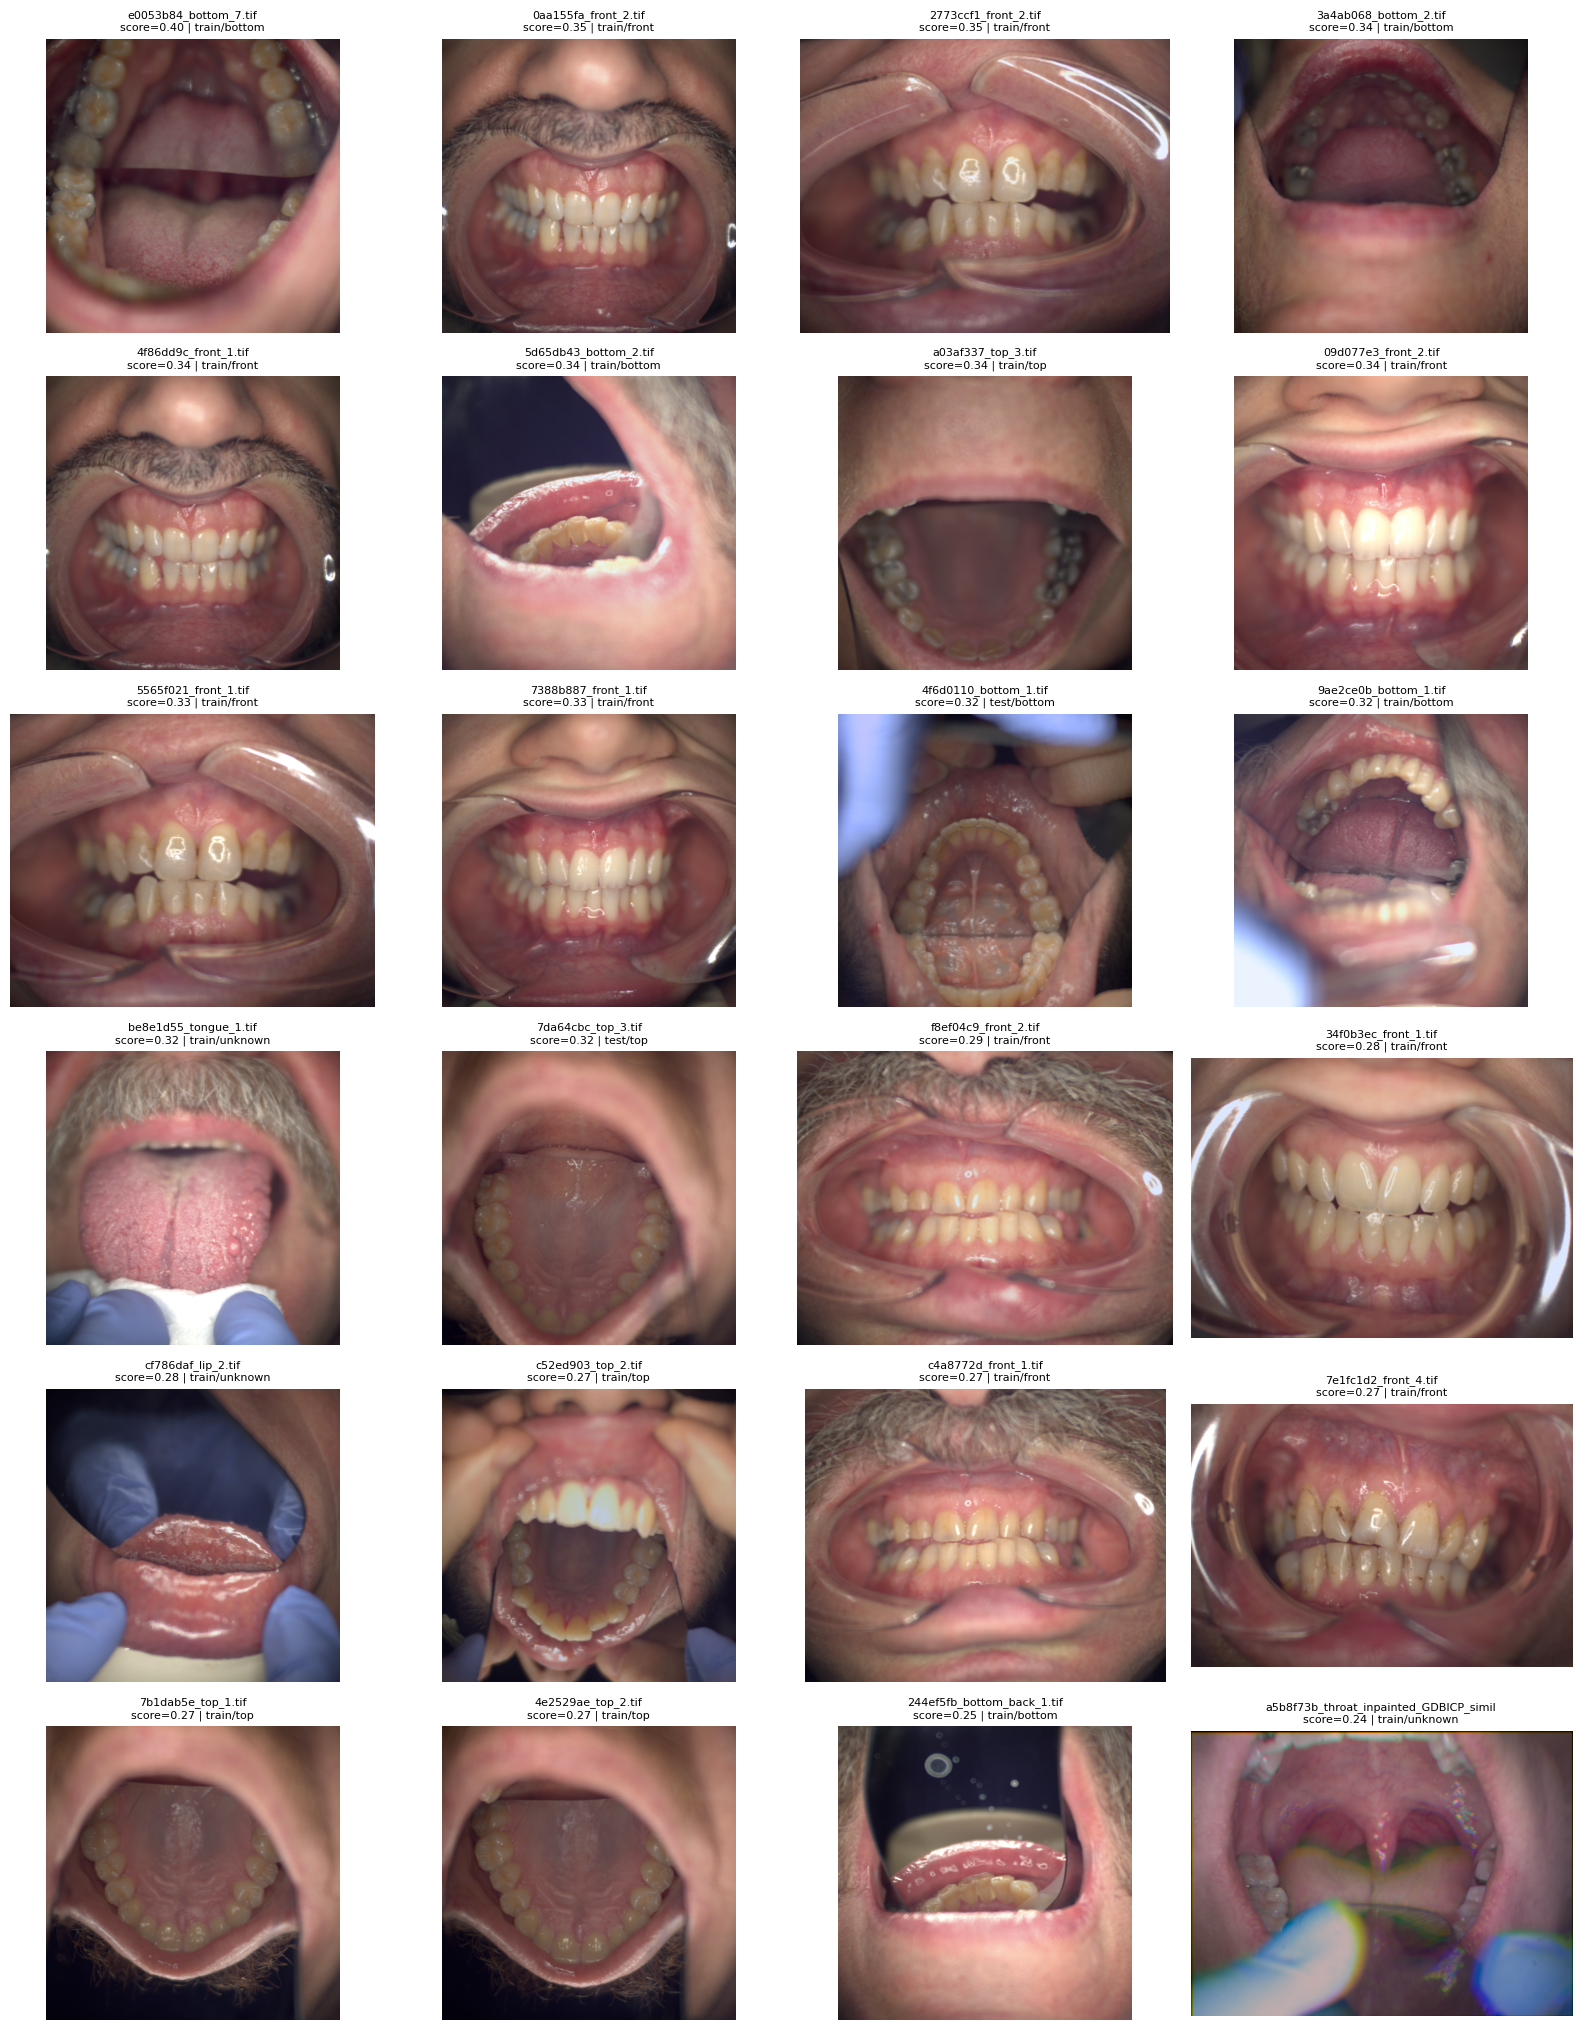

In [7]:
def show_gallery(frame, n=24):
    subset = frame.head(n)
    if subset.empty:
        print('Sem imagens para exibir.')
        return
    cols = 4
    rows = int(np.ceil(len(subset) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.4 * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        ax.axis('off')
    for ax, row in zip(axes, subset.itertuples(index=False)):
        ax.imshow(plt.imread(row.thumbnail))
        title = f'{row.filename[:38]}\nscore={row.selection_score:.2f} | {row.split}/{row.view}'
        ax.set_title(title, fontsize=8)
    plt.tight_layout()
    plt.show()


show_gallery(candidates, n=24)

## Curvas espectrais medias

Esta inspecao ajuda a escolher imagens espectralmente diferentes entre si. Ela relera apenas as primeiras candidatas exibidas.

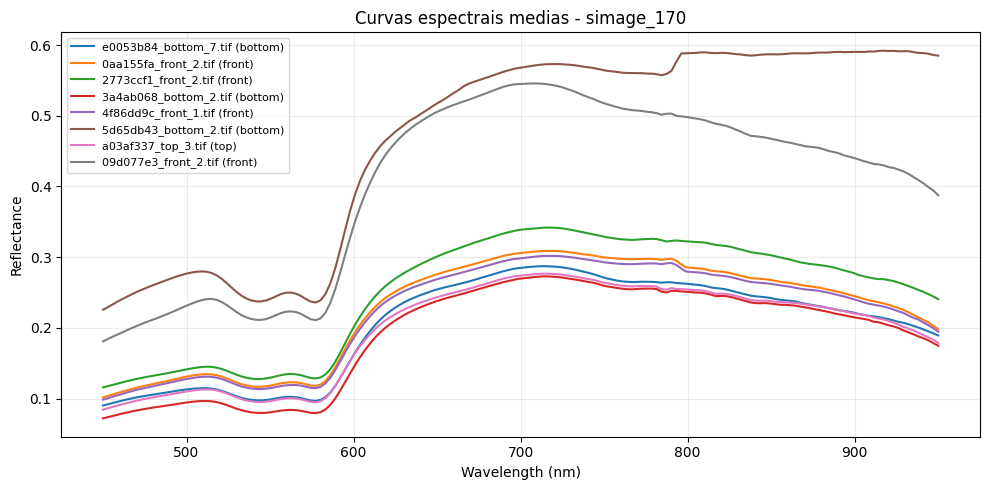

In [8]:
def plot_mean_spectra(frame, n=8):
    subset = frame.head(n)
    plt.figure(figsize=(10, 5))
    for row in subset.itertuples(index=False):
        path = Path(row.path)
        im_hyper, wl, _, _ = read_stiff(str(path), silent=True, rgb_only=False)
        reflectance = LoadImage.read_hyper_reflectance(str(path), MODE, im_hyper=im_hyper, wl=wl)
        sample = sample_pixels(reflectance, MAX_STAT_PIXELS, SEED)
        mean_spectrum = np.nanmean(sample, axis=0)
        label = f'{row.filename[:28]} ({row.view})'
        plt.plot(TARGET_WAVELENGTHS, mean_spectrum, label=label)
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Reflectance')
    plt.title(f'Curvas espectrais medias - {MODE}')
    plt.grid(True, alpha=0.25)
    plt.legend(fontsize=8, loc='best')
    plt.tight_layout()
    plt.show()


plot_mean_spectra(candidates, n=8)

## Selecao final e comandos de treino

Edite `SELECTED_N` ou preencha `MANUAL_FILENAMES` se quiser travar manualmente a lista final.

In [9]:
SELECTED_N = 10
MANUAL_FILENAMES = []  # exemplo: ['ab1b1aad_top_1.tif', '95cf79dd_bottom_1.tif']

if MANUAL_FILENAMES:
    selected = df_ranked[df_ranked['filename'].isin(MANUAL_FILENAMES)].copy()
else:
    selected = candidates.head(SELECTED_N).copy()

OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
selected.to_csv(OUTPUT_CSV, index=False)

print(f'Selecao salva em: {OUTPUT_CSV}')
display(selected[columns])

print('\nComandos de treino sugeridos:')
print('cd /home/ranulfo/projects/tcc/references/segodsidb')
print('source .venv/bin/activate')
for image_path in selected['path'].tolist():
    print(f'python -m torchseg.train -c {CONFIG_PATH.as_posix()} --image-path {image_path}')

Selecao salva em: results/selected_unmixing_images.csv


,filename,split,view,raw_bands,target_bands,reflectance_mean,reflectance_std,dynamic_range_p99_p01,spectral_mean_std,spatial_std_mean,negative_frac,above_one_frac,near_zero_frac,selection_score,path
0,e0053b84_bottom_7.tif,train,bottom,204,170,0.204747,0.185072,0.852977,0.069140,0.163270,0.0,0.0,0.006981,0.398837,../odsi_db/folds/fold_0/train/e0053b84_bottom_...
1,0aa155fa_front_2.tif,train,front,204,170,0.227168,0.184691,0.860440,0.071937,0.165943,0.0,0.0,0.005515,0.353488,../odsi_db/folds/fold_0/train/0aa155fa_front_2...
2,2773ccf1_front_2.tif,train,front,204,170,0.251868,0.197623,0.896028,0.080602,0.177292,0.0,0.0,0.002252,0.346977,../odsi_db/folds/fold_0/train/2773ccf1_front_2...
3,3a4ab068_bottom_2.tif,train,bottom,204,170,0.191005,0.174416,0.730851,0.071692,0.148937,0.0,0.0,0.004598,0.339767,../odsi_db/folds/fold_0/train/3a4ab068_bottom_...
4,4f86dd9c_front_1.tif,train,front,204,170,0.221954,0.180713,0.842530,0.070576,0.161892,0.0,0.0,0.007564,0.338837,../odsi_db/folds/fold_0/train/4f86dd9c_front_1...
5,5d65db43_bottom_2.tif,train,bottom,204,170,0.469485,0.336856,0.987180,0.143006,0.295953,0.0,0.0,0.000628,0.336977,../odsi_db/folds/fold_0/train/5d65db43_bottom_...
6,a03af337_top_3.tif,train,top,204,170,0.199217,0.164022,0.694364,0.066829,0.142089,0.0,0.0,0.002127,0.336512,../odsi_db/folds/fold_0/train/a03af337_top_3.tif
7,09d077e3_front_2.tif,train,front,204,170,0.404298,0.286108,0.962550,0.125370,0.254519,0.0,0.0,0.000000,0.335349,../odsi_db/folds/fold_0/train/09d077e3_front_2...
8,5565f021_front_1.tif,train,front,204,170,0.252534,0.194676,0.913230,0.080959,0.173994,0.0,0.0,0.000552,0.330000,../odsi_db/folds/fold_0/train/5565f021_front_1...
9,7388b887_front_1.tif,train,front,204,170,0.265695,0.201187,0.849126,0.086981,0.177635,0.0,0.0,0.006131,0.328372,../odsi_db/folds/fold_0/train/7388b887_front_1...



Comandos de treino sugeridos:
cd /home/ranulfo/projects/tcc/references/segodsidb
source .venv/bin/activate
python -m torchseg.train -c config_templates/unmixing/odsi_db/repro/fold_0/cnnaeu_simage_170.json --image-path ../odsi_db/folds/fold_0/train/e0053b84_bottom_7.tif
python -m torchseg.train -c config_templates/unmixing/odsi_db/repro/fold_0/cnnaeu_simage_170.json --image-path ../odsi_db/folds/fold_0/train/0aa155fa_front_2.tif
python -m torchseg.train -c config_templates/unmixing/odsi_db/repro/fold_0/cnnaeu_simage_170.json --image-path ../odsi_db/folds/fold_0/train/2773ccf1_front_2.tif
python -m torchseg.train -c config_templates/unmixing/odsi_db/repro/fold_0/cnnaeu_simage_170.json --image-path ../odsi_db/folds/fold_0/train/3a4ab068_bottom_2.tif
python -m torchseg.train -c config_templates/unmixing/odsi_db/repro/fold_0/cnnaeu_simage_170.json --image-path ../odsi_db/folds/fold_0/train/4f86dd9c_front_1.tif
python -m torchseg.train -c config_templates/unmixing/odsi_db/repro/fold_0/cnnae

### Interpretacao rapida

- `spatial_std_mean`: variacao espacial media; maior tende a indicar cena com mais mistura/contraste local.
- `spectral_mean_std`: variacao da curva espectral media; maior tende a indicar assinatura espectral mais marcada.
- `dynamic_range_p99_p01`: faixa dinamica robusta; valores muito baixos indicam cena pouco informativa.
- `negative_frac`, `above_one_frac`, `nonfinite_frac`: diagnosticos de possiveis problemas de escala/dados.
- `selection_score`: ranking pratico para escolher candidatas; use junto com a galeria RGB e as curvas espectrais.